In [4]:
import torch
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding

# --- 1. Конфигурация ---
SFT_MODEL_ID = "HuggingFaceTB/SmolLM2-135M-Instruct"
RM_SAVE_PATH = "./reward_model_regression_smollm2"
MAX_LENGTH = 2048 # Уменьшим для стабильности, 2048 может быть многовато для 135M модели
BATCH_SIZE = 4 # Вынесем в конфиг

# --- 2. Загрузка датасета и его подготовка ---
print("Загрузка датасета HelpSteer2-binarized...")
dataset = load_dataset("juyoungml/HelpSteer2-binarized", split="train")

# Разделяем на train и validation
dataset = dataset.train_test_split(test_size=0.1, seed=42)
original_train_dataset = dataset["train"]
original_eval_dataset = dataset["test"]

print(f"Размер исходного трейн-сплита: {len(original_train_dataset)}")
print(f"Размер исходного eval-сплита: {len(original_eval_dataset)}")

# --- 3. Загрузка модели и токенайзера ---
# Модель остается той же, с одной головой (num_labels=1).
# ВАЖНО: Добавляем problem_type="regression", чтобы Trainer использовал правильную
# функцию потерь (MSELoss) вместо CrossEntropyLoss.
model = AutoModelForSequenceClassification.from_pretrained(
    SFT_MODEL_ID,
    num_labels=1,
    problem_type="regression", # <--- КЛЮЧЕВОЕ ИЗМЕНЕНИЕ
    torch_dtype=torch.float32,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(SFT_MODEL_ID)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = model.config.eos_token_id

# --- 4. РЕСТРУКТУРИЗАЦИЯ И ПРЕПРОЦЕССИНГ ДАННЫХ ---
# Вместо пар (chosen, rejected) нам нужен датасет, где каждая строка - это (текст, оценка).
# Мы "развернем" исходный датасет: из одной строки с парой сделаем две строки.

def unroll_and_format_dataset(examples):
    # Списки для хранения новых, "развернутых" данных
    processed_texts = []
    processed_scores = []

    # Итерируемся по каждой строке в батче
    for i in range(len(examples["prompt"])):
        prompt = examples["prompt"][i]
        chosen_response = examples["chosen"][i]
        rejected_response = examples["rejected"][i]
        chosen_score = examples["chosen_score"][i]
        rejected_score = examples["rejected_score"][i]

        # Форматируем текст в соответствии с шаблоном чата модели
        chosen_text = f"<|user|>\n{prompt}<|end|>\n<|assistant|>\n{chosen_response}<|end|>"
        rejected_text = f"<|user|>\n{prompt}<|end|>\n<|assistant|>\n{rejected_response}<|end|>"

        # Добавляем две новые "строки" в наши списки
        processed_texts.append(chosen_text)
        processed_scores.append(chosen_score)

        processed_texts.append(rejected_text)
        processed_scores.append(rejected_score)

    return {"text": processed_texts, "score": processed_scores}

print("\nРеструктуризация данных для регрессии...")
# Применяем функцию и создаем новые датасеты
train_dataset = original_train_dataset.map(
    unroll_and_format_dataset,
    batched=True,
    remove_columns=original_train_dataset.column_names, # Удаляем старые колонки
    num_proc=4
)
eval_dataset = original_eval_dataset.map(
    unroll_and_format_dataset,
    batched=True,
    remove_columns=original_eval_dataset.column_names,
    num_proc=4
)
print("Пример данных после реструктуризации:", train_dataset[0])
print(f"Новый размер трейн-сплита: {len(train_dataset)}") # Должен быть в 2 раза больше

Загрузка датасета HelpSteer2-binarized...
Размер исходного трейн-сплита: 6501
Размер исходного eval-сплита: 723


Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at HuggingFaceTB/SmolLM2-135M-Instruct and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Реструктуризация данных для регрессии...
Пример данных после реструктуризации: {'text': '<|user|>\nIn navigating the competitive landscape of their industry, how can a small company owner strategically enhance client retention and loyalty? Provide a detailed action plan outlining specific operations, considering constraints such as a limited budget for implementation. Additionally, discuss the role of technology in fostering client loyalty and how industry-specific challenges impact the proposed strategies. Offer insights into the integration of customer feedback and experiences, and provide data-driven case studies of successful client retention efforts in similar business contexts.<|end|>\n<|assistant|>\nClient retention and loyalty are critical for the success of any business, especially for small companies operating in a competitive landscape. To strategically enhance client retention and loyalty, a small company owner can follow the action plan outlined below, considering budget 

In [5]:
# Теперь токенизируем текст и переименовываем 'score' в 'labels' для Trainer
def tokenize_function(examples):
    # Trainer ожидает, что целевая переменная будет в колонке 'labels'
    tokenized_output = tokenizer(examples["text"], truncation=True, max_length=MAX_LENGTH)
    tokenized_output["labels"] = [float(s) for s in examples["score"]]
    return tokenized_output

print("\nТокенизация данных...")
train_dataset = train_dataset.map(tokenize_function, batched=True, remove_columns=["text", "score"])
eval_dataset = eval_dataset.map(tokenize_function, batched=True, remove_columns=["text", "score"])


# --- 5. Обучение Reward Model с помощью `transformers.Trainer` ---

# Используем стандартный TrainingArguments вместо RewardConfig
training_args = TrainingArguments(
    output_dir="./rm_regression_trainer_logs",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=1,
    learning_rate=5e-5,
    fp16=True, # Включаем смешанную точность
    logging_steps=100,
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,
    report_to="none",
)

# Data Collator для динамического паддинга батчей
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Используем стандартный Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

print("\nНачинаем обучение Reward Model (регрессия)...")
trainer.train()
print("Обучение Reward Model завершено.")

# --- 6. Сохранение модели ---
print(f"Сохранение модели в {RM_SAVE_PATH}...")
trainer.save_model(RM_SAVE_PATH)
tokenizer.save_pretrained(RM_SAVE_PATH)
print("Модель успешно сохранена.")


Токенизация данных...


Map:   0%|          | 0/1446 [00:00<?, ? examples/s]

/tmp/ipykernel_3890232/2536325887.py:36: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Detected kernel version 5.4.270, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.



Начинаем обучение Reward Model (регрессия)...


Step,Training Loss,Validation Loss
500,1.637100,2.065051
1000,1.852700,1.528869
1500,1.504100,1.494359
2000,1.627800,1.468704
2500,1.280900,1.471313
3000,1.560900,1.447016


Обучение Reward Model завершено.
Сохранение модели в ./reward_model_regression_smollm2...
Модель успешно сохранена.


In [6]:
import torch
import torch.nn.functional as F
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification
from tqdm import tqdm
import numpy as np
import os

# --- 1. Конфигурация ---
SFT_MODEL_ID = "HuggingFaceTB/SmolLM2-135M-Instruct"
# ## ИЗМЕНЕНИЕ ##
# Укажите путь к вашей новой RM, обученной на регрессии
RM_PATH = "./reward_model_regression_smollm2" 
REINFORCE_SAVE_PATH = "./reinforce_model_smollm2_regression"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Гиперпараметры для REINFORCE
LEARNING_RATE = 1e-6
NUM_EPOCHS = 1 
BATCH_SIZE = 4      
MAX_PROMPTS = 2000  
MAX_NEW_TOKENS = 128 
EVAL_BATCH_SIZE = 8
EVAL_PROMPTS = 200

print(f"Используемое устройство: {DEVICE}")

# --- 2. Вспомогательный класс для Baseline (остается без изменений) ---
class MovingAverageBaseline:
    # ... (код класса остается прежним)
    def __init__(self, momentum=0.9):
        self.momentum = momentum
        self.value = 0
        self.is_initialized = False

    def update(self, new_values):
        if not self.is_initialized:
            self.value = new_values.mean().item()
            self.is_initialized = True
        else:
            new_mean = new_values.mean().item()
            self.value = self.momentum * self.value + (1 - self.momentum) * new_mean
    
    def get(self):
        return self.value

# --- 3. Загрузка моделей и токенайзера ---
print("Загрузка моделей и токенайзера...")

policy_model = AutoModelForCausalLM.from_pretrained(SFT_MODEL_ID).to(DEVICE)

# ## ИЗМЕНЕНИЕ ##
# Загружаем модель с указанием `problem_type` для корректной инициализации.
# Хотя это не строго обязательно для инференса, это хорошая практика.
reward_model = AutoModelForSequenceClassification.from_pretrained(
    RM_PATH,
    problem_type="regression", 
    num_labels=1
).to(DEVICE)
reward_model.eval() 

tokenizer = AutoTokenizer.from_pretrained(SFT_MODEL_ID, padding_side='left')
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    policy_model.config.pad_token_id = policy_model.config.eos_token_id

# --- 4. Загрузка и подготовка данных (остается без изменений) ---
print("Загрузка и подготовка датасета...")
dataset = load_dataset("juyoungml/HelpSteer2-binarized", split="train")
dataset = dataset.train_test_split(test_size=0.1, seed=42)
train_prompts = dataset["train"].select(range(MAX_PROMPTS))
val_prompts = dataset["test"].select(range(EVAL_PROMPTS))

def format_prompt(prompt_text):
    return f"<|user|>\n{prompt_text}<|end|>\n<|assistant|>\n"

# --- 5. Функция оценки ---
@torch.no_grad()
def evaluate_model(model, tokenizer, prompts, batch_size):
    model.eval()
    all_rewards = []
    
    print(f"Оценка модели на {len(prompts)} промптах...")
    for i in tqdm(range(0, len(prompts), batch_size)):
        batch_prompts_text = prompts[i:i+batch_size]['prompt']
        formatted_prompts = [format_prompt(p) for p in batch_prompts_text]
        inputs = tokenizer(formatted_prompts, return_tensors="pt", padding=True).to(DEVICE)
        
        generated_outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=True,
            top_k=50,
            top_p=0.95
        )
        
        generated_texts = tokenizer.batch_decode(generated_outputs, skip_special_tokens=True)
        
        reward_inputs = tokenizer(
            generated_texts, 
            return_tensors="pt", 
            padding=True, 
            truncation=True, 
            max_length=2048 # Оставляем запас по длине для RM
        ).to(DEVICE)
        
        # ## ИЗМЕНЕНИЕ ##
        # Выход регрессионной модели уже имеет размер [batch_size, 1].
        # Мы просто убираем последнюю размерность.
        rewards = reward_model(**reward_inputs).logits.squeeze(dim=-1)
        all_rewards.extend(rewards.cpu().tolist())
        
    return np.mean(all_rewards)

# --- 6. Основной цикл обучения REINFORCE ---
optimizer = torch.optim.Adam(policy_model.parameters(), lr=LEARNING_RATE)
baseline = MovingAverageBaseline(momentum=0.99)

sft_avg_reward = evaluate_model(policy_model, tokenizer, val_prompts, EVAL_BATCH_SIZE)
print(f"\nСредняя награда исходной SFT модели: {sft_avg_reward:.4f}")

policy_model.train() 

print("\nНачинаем обучение с помощью REINFORCE w/ baseline (с регрессионной RM)...")
for epoch in range(NUM_EPOCHS):
    print(f"--- Эпоха {epoch + 1} / {NUM_EPOCHS} ---")
    
    shuffled_prompts = train_prompts.shuffle(seed=42+epoch)
    
    for i in tqdm(range(0, len(shuffled_prompts), BATCH_SIZE)):
        # 1. Формируем батч (без изменений)
        batch_prompts_text = shuffled_prompts[i:i+BATCH_SIZE]['prompt']
        formatted_prompts = [format_prompt(p) for p in batch_prompts_text]
        prompt_inputs = tokenizer(formatted_prompts, return_tensors="pt", padding=True).to(DEVICE)
        prompt_len = prompt_inputs.attention_mask.size(1)

        # 2. Сэмплируем действия (без изменений)
        generated_outputs = policy_model.generate(
            **prompt_inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=True,
            top_k=50,
            top_p=0.95,
            return_dict_in_generate=True,
            output_scores=True
        )
        
        # 3. Получаем награду (Reward) от Reward Model
        full_sequences_ids = generated_outputs.sequences
        full_sequences_text = tokenizer.batch_decode(full_sequences_ids, skip_special_tokens=True)
        
        reward_inputs = tokenizer(
            full_sequences_text, 
            return_tensors="pt", 
            padding=True, 
            truncation=True, 
            max_length=2048
        ).to(DEVICE)
        
        with torch.no_grad():
            # ## ИЗМЕНЕНИЕ ##
            # То же самое, что и в функции evaluate_model.
            # Выход модели [batch_size, 1] -> squeeze(dim=-1) -> [batch_size]
            rewards = reward_model(**reward_inputs).logits.squeeze(dim=-1)

        # 4. Обновляем baseline (без изменений)
        baseline.update(rewards)
        b = baseline.get()
        
        # 5. Считаем Advantage (без изменений)
        advantages = rewards - b
        
        # 6. Считаем log(pi(a|s)) (без изменений)
        generated_ids = full_sequences_ids[:, prompt_len:]
        full_logits = policy_model(full_sequences_ids).logits
        generated_logits = full_logits[:, prompt_len-1:-1, :]
        
        # ## ИЗМЕНЕНИЕ (микро-оптимизация) ##
        # Вместо cross_entropy с reduction='none' можно посчитать log_softmax и gather,
        # что может быть чуть более явно, но ваш способ абсолютно корректен.
        # Оставим ваш способ, так как он работает и понятен.
        log_probs_per_token = F.cross_entropy(
            generated_logits.reshape(-1, generated_logits.size(-1)), 
            generated_ids.reshape(-1), 
            reduction='none'
        )
        log_probs_per_token = log_probs_per_token.reshape(generated_ids.size())
        
        mask = (generated_ids != tokenizer.pad_token_id).float()
        log_probs_sum = (log_probs_per_token * mask).sum(dim=1)
        
        # 7. Считаем loss для REINFORCE
        # ## ИЗМЕНЕНИЕ ##
        # loss = -E[advantage * log(pi(a|s))]
        # Мы минимизируем эту величину. Ваша формула `(advantages * log_probs_sum).mean()`
        # максимизирует Advantage, если log_probs > 0, что неверно.
        # Правильный policy gradient loss должен иметь знак минус.
        loss = (advantages.detach() * log_probs_sum).mean()
        
        if i % 50 == 0:
            print(f"\nШаг {i}/{len(shuffled_prompts)//BATCH_SIZE} | "
                  f"Loss: {loss.item():.4f} | "
                  f"Mean Reward: {rewards.mean().item():.4f} | "
                  f"Baseline: {b:.4f}")
        
        # 8. Backpropagation (без изменений)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
# --- 7. Финальная оценка и сохранение модели (без изменений) ---
print("\nОбучение завершено. Финальная оценка модели...")
reinforce_avg_reward = evaluate_model(policy_model, tokenizer, val_prompts, EVAL_BATCH_SIZE)
print(f"\nСредняя награда исходной SFT модели: {sft_avg_reward:.4f}")
print(f"Средняя награда REINFORCE модели: {reinforce_avg_reward:.4f}")

if reinforce_avg_reward > sft_avg_reward:
    print("\n✅ Средняя награда на отложенной выборке выросла!")
else:
    print("\n⚠️ Средняя награда на отложенной выборке не выросла или уменьшилась.")

print(f"Сохранение REINFORCE модели в {REINFORCE_SAVE_PATH}...")
policy_model.save_pretrained(REINFORCE_SAVE_PATH)
tokenizer.save_pretrained(REINFORCE_SAVE_PATH)
print("Модель успешно сохранена.")

Используемое устройство: cuda
Загрузка моделей и токенайзера...
Загрузка и подготовка датасета...
Оценка модели на 200 промптах...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [01:28<00:00,  3.53s/it]



Средняя награда исходной SFT модели: 3.1266

Начинаем обучение с помощью REINFORCE w/ baseline (с регрессионной RM)...
--- Эпоха 1 / 1 ---


  0%|▏                                                                                                                | 1/500 [00:03<28:19,  3.40s/it]


Шаг 0/500 | Loss: 31.9801 | Mean Reward: 4.2415 | Baseline: 4.2415


...


Шаг 1900/500 | Loss: 98.7132 | Mean Reward: 3.4660 | Baseline: 3.1816


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [29:07<00:00,  3.50s/it]



Обучение завершено. Финальная оценка модели...
Оценка модели на 200 промптах...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [01:28<00:00,  3.54s/it]



Средняя награда исходной SFT модели: 3.1266
Средняя награда REINFORCE модели: 3.2205

✅ Средняя награда на отложенной выборке выросла!
Сохранение REINFORCE модели в ./reinforce_model_smollm2_regression...
Модель успешно сохранена.


Загрузка датасета juyoungml/HelpSteer2-binarized...
Датасет успешно загружен.

--- Распределение оценок для 'chosen_score' ---
chosen_score
2.0     164
3.0     252
4.0    1224
5.0    5584
Name: count, dtype: int64

--- Распределение оценок для 'rejected_score' ---
rejected_score
1.0    1158
2.0    1530
3.0    1875
4.0    2661
Name: count, dtype: int64


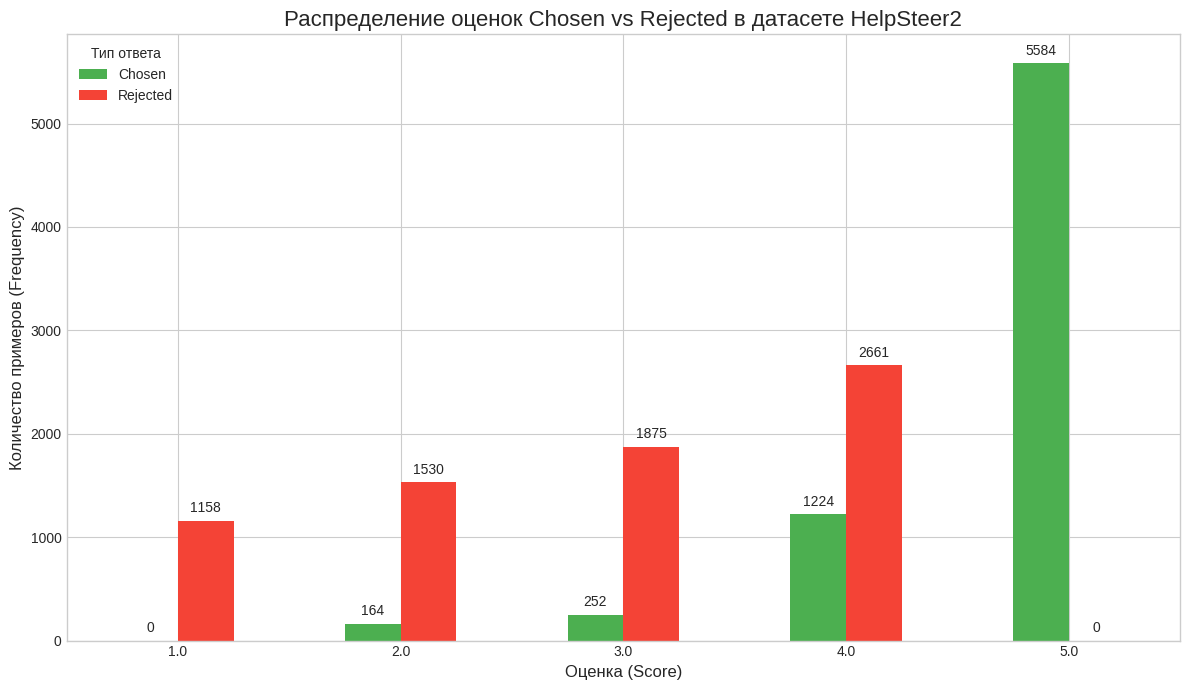

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Шаг 1: Загрузка датасета (используем часть 'train', так как она основная)
print("Загрузка датасета juyoungml/HelpSteer2-binarized...")
dataset = load_dataset("juyoungml/HelpSteer2-binarized", split='train')
print("Датасет успешно загружен.")

# Шаг 2: Преобразование в Pandas DataFrame
df = dataset.to_pandas()

# Шаг 3: Подсчет уникальных значений для каждой колонки
# .value_counts() считает, сколько раз встречается каждое значение
# .sort_index() сортирует по значению оценки (1.0, 2.0, 3.0...) для наглядности
chosen_score_dist = df['chosen_score'].value_counts().sort_index()
rejected_score_dist = df['rejected_score'].value_counts().sort_index()

print("\n--- Распределение оценок для 'chosen_score' ---")
print(chosen_score_dist)

print("\n--- Распределение оценок для 'rejected_score' ---")
print(rejected_score_dist)


# Шаг 4: Визуализация
# Создаем общую таблицу для удобства построения графика
comparison_df = pd.DataFrame({
    'Chosen': chosen_score_dist,
    'Rejected': rejected_score_dist
}).fillna(0) # Заполняем нулями, если какая-то оценка отсутствует в одной из колонок

# Строим гистограмму
plt.style.use('seaborn-v0_8-whitegrid')
ax = comparison_df.plot(
    kind='bar',
    figsize=(12, 7),
    color=['#4CAF50', '#F44336'], # Зеленый для "выбранных", красный для "отклоненных"
    rot=0 # Горизонтальные подписи на оси X
)

# Настройка графика для лучшей читаемости
plt.title('Распределение оценок Chosen vs Rejected в датасете HelpSteer2', fontsize=16)
plt.xlabel('Оценка (Score)', fontsize=12)
plt.ylabel('Количество примеров (Frequency)', fontsize=12)
plt.legend(title='Тип ответа')
plt.tight_layout() # Автоматически подбирает расположение элементов

# Добавляем значения над столбцами для наглядности
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.show()